<h1>👤 CelebA</h1>
<h4 style="color:#555; margin-top:-8px;">
CelebFaces Attributes Dataset — Multi-Label Face Attribute Classification
</h4>
<hr style="border:1px solid #ddd;">

<div style="background-color: #f0f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #3498db;">

<h4>🎯 Objective</h4>
Build a <strong>multi-label face attribute classifier</strong> using the CelebA dataset — predicting 40 binary facial attributes (e.g., Smiling, Young, Eyeglasses) from aligned face images using a pretrained CNN backbone.

</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📂 Dataset Overview</h3>
</div>

**Dataset:** CelebFaces Attributes (CelebA)

**Files Used:** `list_attr_celeba.csv`, `list_eval_partition.csv`, `img_align_celeba/`  
**Dataset Source:** MMLAB, The Chinese University of Hong Kong  
**URL:** https://www.kaggle.com/datasets/jessicali9530/celeba-dataset

**Attribute File (`list_attr_celeba.csv`) — Raw Features**
| Feature | Description |
| --- | --- |
| `image_id` | Filename of the face image (e.g., `000001.jpg`) |
| `5_o_Clock_Shadow` ... `Young` | 40 binary attributes, originally encoded as -1 / 1 |

**Partition File (`list_eval_partition.csv`) — Split**
| Feature | Description |
| --- | --- |
| `image_id` | Filename of the face image |
| `partition` | 0 = Train, 1 = Validation, 2 = Test |


<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">

## Dataset Attribute Summary

The dataset contains **202,599 records** with **40 facial attribute features** along with one identifier column (image name).

### Dataset Structure

| Property | Description |
|--------|-------------|
| Total Images | 202,599 |
| Total Attributes | 40 |
| Data Types | 40 `int64` columns, 1 `object` column |
| Missing Values | None |
| Memory Usage | ~63.4 MB |

### Attribute Description

Each of the 40 attributes represents a **binary facial feature** associated with an image.  
The attributes indicate whether a particular characteristic is **present or absent**.

The attributes include physical traits, facial structures, expressions, and accessories.

**Examples of attributes include:**

- **Hair Features:** `Black_Hair`, `Blond_Hair`, `Brown_Hair`, `Gray_Hair`, `Bald`
- **Facial Structure:** `High_Cheekbones`, `Oval_Face`, `Pointy_Nose`
- **Facial Hair:** `Mustache`, `Goatee`, `No_Beard`, `Sideburns`
- **Expressions:** `Smiling`, `Mouth_Slightly_Open`
- **Accessories:** `Eyeglasses`, `Wearing_Hat`, `Wearing_Earrings`, `Wearing_Necktie`
- **Appearance Attributes:** `Heavy_Makeup`, `Rosy_Cheeks`, `Pale_Skin`
- **Demographic Indicators:** `Male`, `Young`

### Encoding

Each attribute is encoded as a **binary value**, where:

- **1** → Feature is present  
- **0 or -1** → Feature is absent (depending on preprocessing)

### Use Cases

This dataset is commonly used for:

- **Facial attribute recognition**
- **Multi-label classification**
- **Computer vision model training**
- **Deep learning experiments**
- **Image feature analysis**

**Importing Required Libraries**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from PIL import Image
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,confusion_matrix, mean_squared_error, mean_absolute_error)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')


**Loading the Dataset**

In [2]:
DATA_ROOT = Path().resolve() / '.data' / 'celeba'
IMG_DIR = DATA_ROOT / 'img_align_celeba' / 'img_align_celeba'
ATTR_FILE = DATA_ROOT / 'list_attr_celeba.csv'
PART_FILE = DATA_ROOT / 'list_eval_partition.csv'

df_attr = pd.read_csv(ATTR_FILE)
df_part = pd.read_csv(PART_FILE)

attr_cols = [c for c in df_attr.columns if c != 'image_id']
df_attr[attr_cols] = df_attr[attr_cols].replace(-1, 0)

df = df_attr.merge(df_part, on='image_id')

print("Attributes shape:", df_attr.shape)
print("Partition shape:", df_part.shape)
print("Merged shape:", df.shape)

Attributes shape: (202599, 41)
Partition shape: (202599, 2)
Merged shape: (202599, 42)


In [3]:
df_attr.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,0,1,1,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
1,000002.jpg,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
2,000003.jpg,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
3,000004.jpg,0,0,1,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
4,000005.jpg,0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1


In [4]:
df_part.head()

,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🔍 Data Quality Check</h3>
</div>

In [5]:
df_attr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202599 entries, 0 to 202598
Data columns (total 41 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   image_id             202599 non-null  object
 1   5_o_Clock_Shadow     202599 non-null  int64 
 2   Arched_Eyebrows      202599 non-null  int64 
 3   Attractive           202599 non-null  int64 
 4   Bags_Under_Eyes      202599 non-null  int64 
 5   Bald                 202599 non-null  int64 
 6   Bangs                202599 non-null  int64 
 7   Big_Lips             202599 non-null  int64 
 8   Big_Nose             202599 non-null  int64 
 9   Black_Hair           202599 non-null  int64 
 10  Blond_Hair           202599 non-null  int64 
 11  Blurry               202599 non-null  int64 
 12  Brown_Hair           202599 non-null  int64 
 13  Bushy_Eyebrows       202599 non-null  int64 
 14  Chubby               202599 non-null  int64 
 15  Double_Chin          202599 non-nu

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">


### Attribute Categories


| Hair-related Attributes | Facial Hair | Facial Structure | Facial Expressions | Appearance & Skin Features | Accessories | Demographic Indicators |
|-------------------------|-------------|------------------|-------------------|-----------------------------|-------------|------------------------|
| Black_Hair | Mustache | High_Cheekbones | Smiling | Pale_Skin | Eyeglasses | Male |
| Blond_Hair | Goatee | Oval_Face | Mouth_Slightly_Open | Rosy_Cheeks | Wearing_Earrings | Young |
| Brown_Hair | Sideburns | Pointy_Nose |  | Heavy_Makeup | Wearing_Hat |  |
| Gray_Hair | No_Beard | Big_Nose |  | Bags_Under_Eyes | Wearing_Lipstick |  |
| Bald | 5_o_Clock_Shadow | Chubby |  | Blurry | Wearing_Necklace |  |
| Bangs |  | Double_Chin |  |  |  |  |
| Receding_Hairline |  |  |  |  |  |  |
| Straight_Hair |  |  |  |  |  |  |
| Wavy_Hair |  |  |  |  |  |  |
### Summary

- The dataset is **fully complete with no missing values**.
- Each image is associated with **40 binary facial attributes**, making it suitable for **multi-label classification tasks in computer vision**.
- The structure allows models to **predict multiple facial characteristics simultaneously from a single image**.

In [6]:
df_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202599 entries, 0 to 202598
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   image_id   202599 non-null  object
 1   partition  202599 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">

## Partition Dataset Summary

This dataset segment contains **202,599 records** and **2 columns** used to identify images and their dataset split.

### Dataset Structure

| Column Name | Data Type | Description |
|-------------|-----------|-------------|
| image_id | object | Unique identifier or filename for each image |
| partition | int64 | Indicates the dataset split (training, validation, or testing) |

### Key Details

- **Total Rows:** 202,599  
- **Total Columns:** 2  
- **Missing Values:** None (all columns contain 202,599 non-null entries)  
- **Memory Usage:** ~3.1 MB  

### Purpose

The `partition` column is used to **divide the dataset into subsets** typically used in machine learning workflows:

- **0 → Training set**
- **1 → Validation set**
- **2 → Test set**

This structure allows models to be **trained, tuned, and evaluated properly without data leakage**.

#### Checking for NULL VALUES

In [7]:
df_attr.isnull().sum()

image_id               0
5_o_Clock_Shadow       0
Arched_Eyebrows        0
Attractive             0
Bags_Under_Eyes        0
Bald                   0
Bangs                  0
Big_Lips               0
Big_Nose               0
Black_Hair             0
Blond_Hair             0
Blurry                 0
Brown_Hair             0
Bushy_Eyebrows         0
Chubby                 0
Double_Chin            0
Eyeglasses             0
Goatee                 0
Gray_Hair              0
Heavy_Makeup           0
High_Cheekbones        0
Male                   0
Mouth_Slightly_Open    0
Mustache               0
Narrow_Eyes            0
No_Beard               0
Oval_Face              0
Pale_Skin              0
Pointy_Nose            0
Receding_Hairline      0
Rosy_Cheeks            0
Sideburns              0
Smiling                0
Straight_Hair          0
Wavy_Hair              0
Wearing_Earrings       0
Wearing_Hat            0
Wearing_Lipstick       0
Wearing_Necklace       0
Wearing_Necktie        0


In [8]:
df_part.isnull().sum()

image_id     0
partition    0
dtype: int64

#### Checking for any MISSING Values

In [9]:
df_attr.isna().sum()

image_id               0
5_o_Clock_Shadow       0
Arched_Eyebrows        0
Attractive             0
Bags_Under_Eyes        0
Bald                   0
Bangs                  0
Big_Lips               0
Big_Nose               0
Black_Hair             0
Blond_Hair             0
Blurry                 0
Brown_Hair             0
Bushy_Eyebrows         0
Chubby                 0
Double_Chin            0
Eyeglasses             0
Goatee                 0
Gray_Hair              0
Heavy_Makeup           0
High_Cheekbones        0
Male                   0
Mouth_Slightly_Open    0
Mustache               0
Narrow_Eyes            0
No_Beard               0
Oval_Face              0
Pale_Skin              0
Pointy_Nose            0
Receding_Hairline      0
Rosy_Cheeks            0
Sideburns              0
Smiling                0
Straight_Hair          0
Wavy_Hair              0
Wearing_Earrings       0
Wearing_Hat            0
Wearing_Lipstick       0
Wearing_Necklace       0
Wearing_Necktie        0


In [10]:
df_part.isna().sum()

image_id     0
partition    0
dtype: int64

#### Checking for duplicate values 

In [11]:
df_attr.duplicated().sum()

np.int64(0)

In [12]:
df_part.duplicated().sum()

np.int64(0)

#### Categorizing Train, Validation and Test DF

In [13]:
df_train = df[df.partition == 0]
df_val = df[df.partition == 1]
df_test = df[df.partition == 2]

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")
print(f"Total attributes: {len(attr_cols)}")

Train: 162,770 | Val: 19,867 | Test: 19,962
Total attributes: 40



<div style="background-color:#fff9c4; padding:16px; border-radius:8px; border-left:5px solid #fbc02d;">

## Data Quality and Dataset Split Summary

### Data Quality Checks

Several checks were performed to ensure the integrity of the attribute dataset:

| Check | Result |
|------|--------|
| Null values | 0 |
| Missing values (NaN) | 0 |
| Duplicate rows | 0 |

These results confirm that the dataset is **clean, complete, and free of duplicates**, making it suitable for machine learning and analytical tasks without additional data cleaning.

### Dataset Partitioning

The dataset was split into **training, validation, and testing sets** using the `partition` column.

| Dataset Split | Number of Samples |
|---------------|------------------|
| Training Set | 162,770 |
| Validation Set | 19,867 |
| Test Set | 19,962 |

### Attribute Information

- **Total attributes:** 40  
- These attributes represent **binary facial features** associated with each image.

### Summary

- The dataset contains **no missing or duplicate values**.
- Data has been **properly partitioned into train, validation, and test sets**.
- The dataset includes **40 facial attributes**, making it suitable for **multi-label classification and computer vision tasks**.

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📊 Exploratory Data Analysis</h3>
</div>

In [14]:
features = df[attr_cols].mean().sort_values(ascending=False)
features

No_Beard               0.834940
Young                  0.773617
Attractive             0.512505
Mouth_Slightly_Open    0.483428
Smiling                0.482080
Wearing_Lipstick       0.472436
High_Cheekbones        0.455032
Male                   0.416754
Heavy_Makeup           0.386922
Wavy_Hair              0.319567
Oval_Face              0.284143
Pointy_Nose            0.277445
Arched_Eyebrows        0.266981
Big_Lips               0.240796
Black_Hair             0.239251
Big_Nose               0.234532
Straight_Hair          0.208402
Brown_Hair             0.205194
Bags_Under_Eyes        0.204572
Wearing_Earrings       0.188925
Bangs                  0.151575
Blond_Hair             0.147992
Bushy_Eyebrows         0.142168
Wearing_Necklace       0.122967
Narrow_Eyes            0.115149
5_o_Clock_Shadow       0.111136
Receding_Hairline      0.079778
Wearing_Necktie        0.072715
Rosy_Cheeks            0.065721
Eyeglasses             0.065119
Goatee                 0.062764
Chubby  

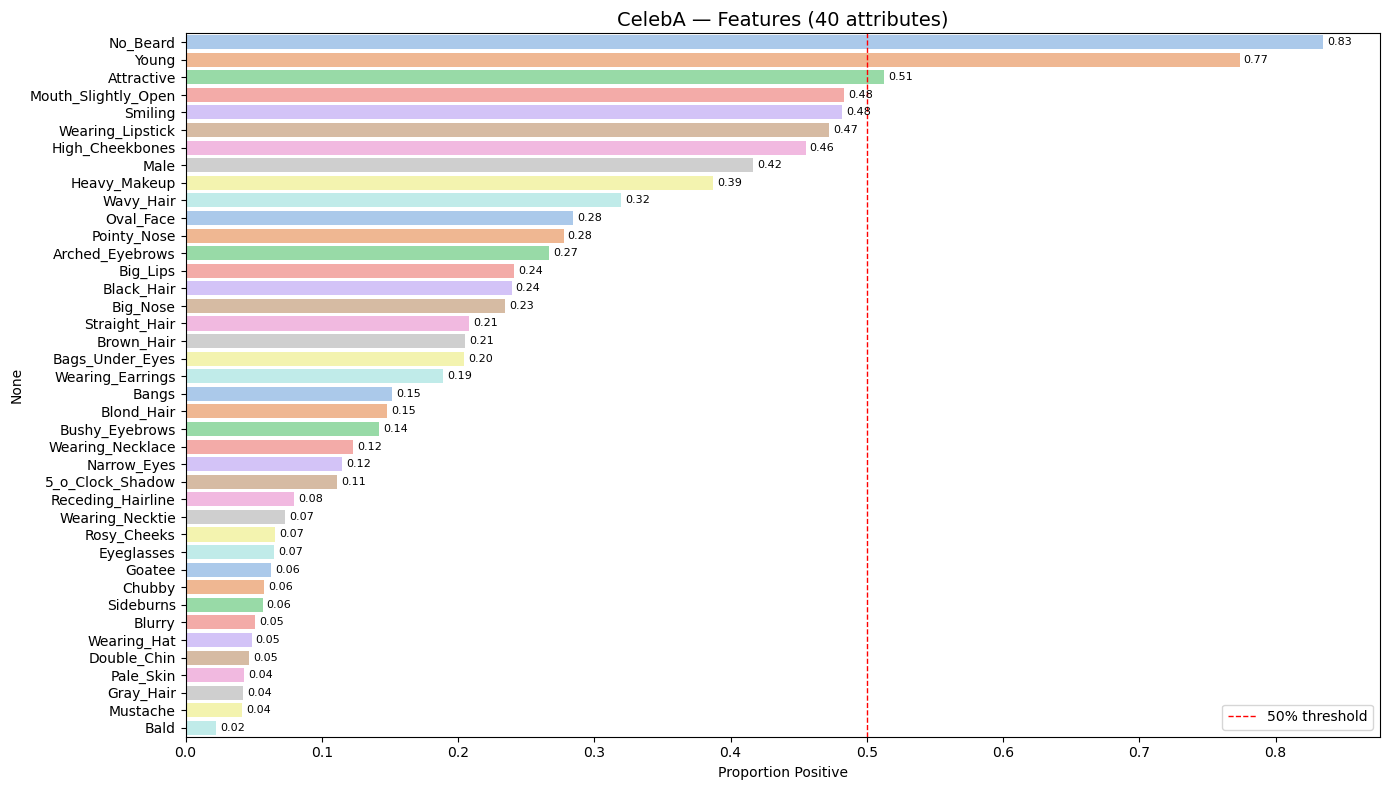

In [15]:
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(x=features.values, y=features.index, palette='pastel', ax=ax)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)
ax.set_xlabel('Proportion Positive')
ax.set_title('CelebA — Features (40 attributes)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
df['n_labels'] = df[attr_cols].sum(axis=1)
df['n_labels'].describe()

count    202599.000000
mean          9.033613
std           2.941745
min           1.000000
25%           7.000000
50%           9.000000
75%          11.000000
max          20.000000
Name: n_labels, dtype: float64

In [22]:
bins = range(df['n_labels'].min(), df['n_labels'].max() + 2)

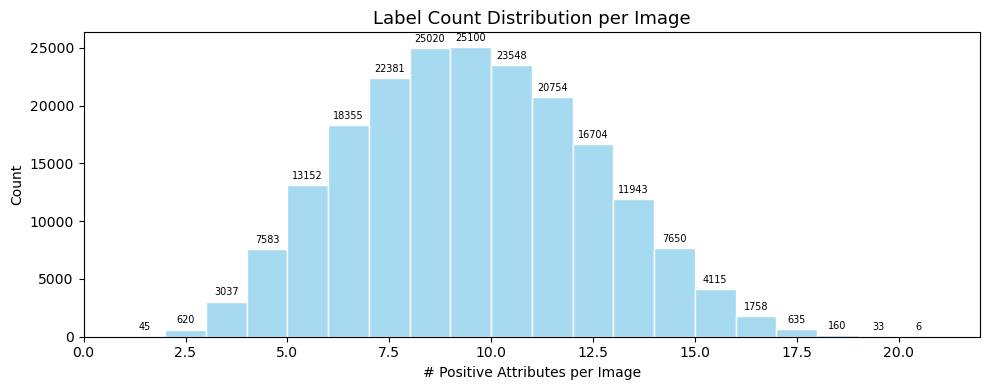

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['n_labels'], bins=bins, ax=ax, color='skyblue', edgecolor='white')
ax.set_xlabel('# Positive Attributes per Image')
ax.set_ylabel('Count')
ax.set_title('Label Count Distribution per Image', fontsize=13)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=7)

plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">

## Label Count Distribution per Image

The histogram shows the **distribution of positive facial attributes per image** across the dataset.

How many of the 40 attributes are positive (=1) per image. For example, if a face has Smiling=1, Young=1, Attractive=1 and everything else=0, that image has n_labels=3. The histogram shows whether most faces have few or many attributes, and if the distribution is skewed.

### Key Insights

- Most images contain **between 7 and 12 positive attributes**.
- The distribution is **roughly bell-shaped**, indicating that most faces share a moderate number of attributes.
- Very few images contain **extremely low (<3)** or **very high (>17)** numbers of attributes.
- The **peak of the distribution appears around 9–10 attributes**, meaning this is the most common number of facial features present in an image.

### Interpretation

This distribution suggests that the dataset has a **balanced variety of facial characteristics**, which is beneficial for training machine learning models.  
Since most samples contain multiple attributes, the dataset is well-suited for **multi-label classification tasks**, where models learn to predict several facial features simultaneously.

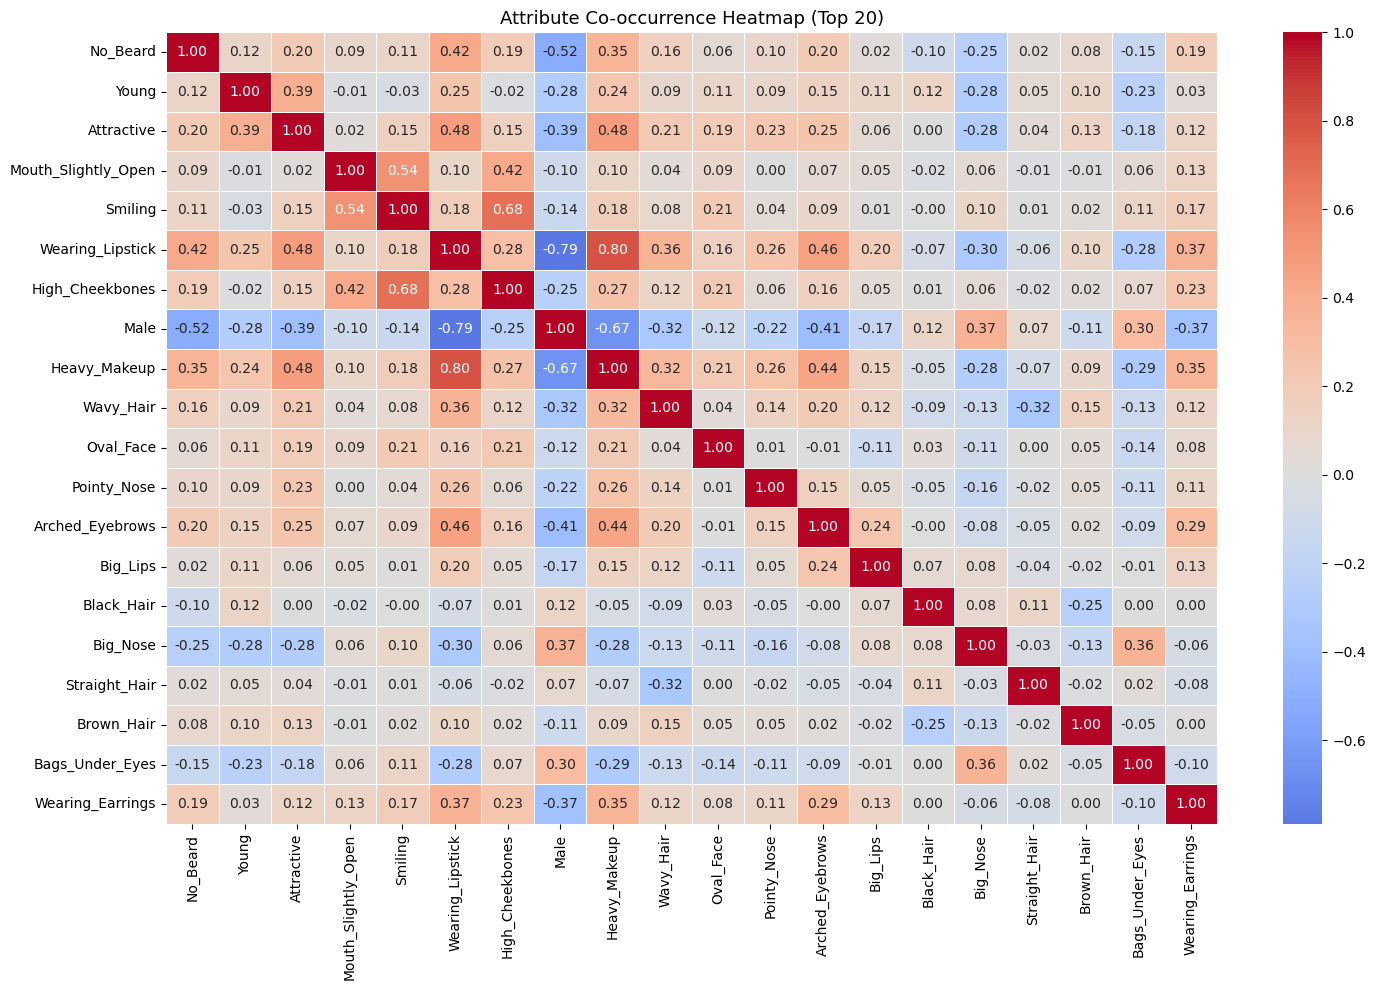

In [18]:
top20 = features.head(20).index.tolist()
corr = df[top20].corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Attribute Co-occurrence Heatmap (Top 20)', fontsize=13)
plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">

## Attribute Co-occurrence Heatmap (Top 20)

The heatmap illustrates the **correlation between the top 20 facial attributes** in the dataset. Each value represents how frequently two attributes appear together.

### Key Observations

- **Strong positive correlations**
  - `Heavy_Makeup` and `Wearing_Lipstick` show a strong positive relationship.
  - `Smiling` and `High_Cheekbones` tend to appear together.
  - `Attractive` has moderate positive correlations with features such as `Smiling` and `Heavy_Makeup`.

- **Negative correlations**
  - `Male` is negatively correlated with attributes such as `Wearing_Lipstick` and `Heavy_Makeup`.
  - `No_Beard` shows negative correlation with facial hair attributes.

- **Hair-related relationships**
  - Hair attributes such as `Black_Hair`, `Brown_Hair`, and `Straight_Hair` show mild relationships with other facial features.

### Interpretation

- The heatmap helps identify **which facial attributes commonly appear together**.
- Strong correlations can indicate **shared visual patterns or demographic associations**.
- Understanding these relationships can help improve **feature engineering and model performance in multi-label classification tasks**.

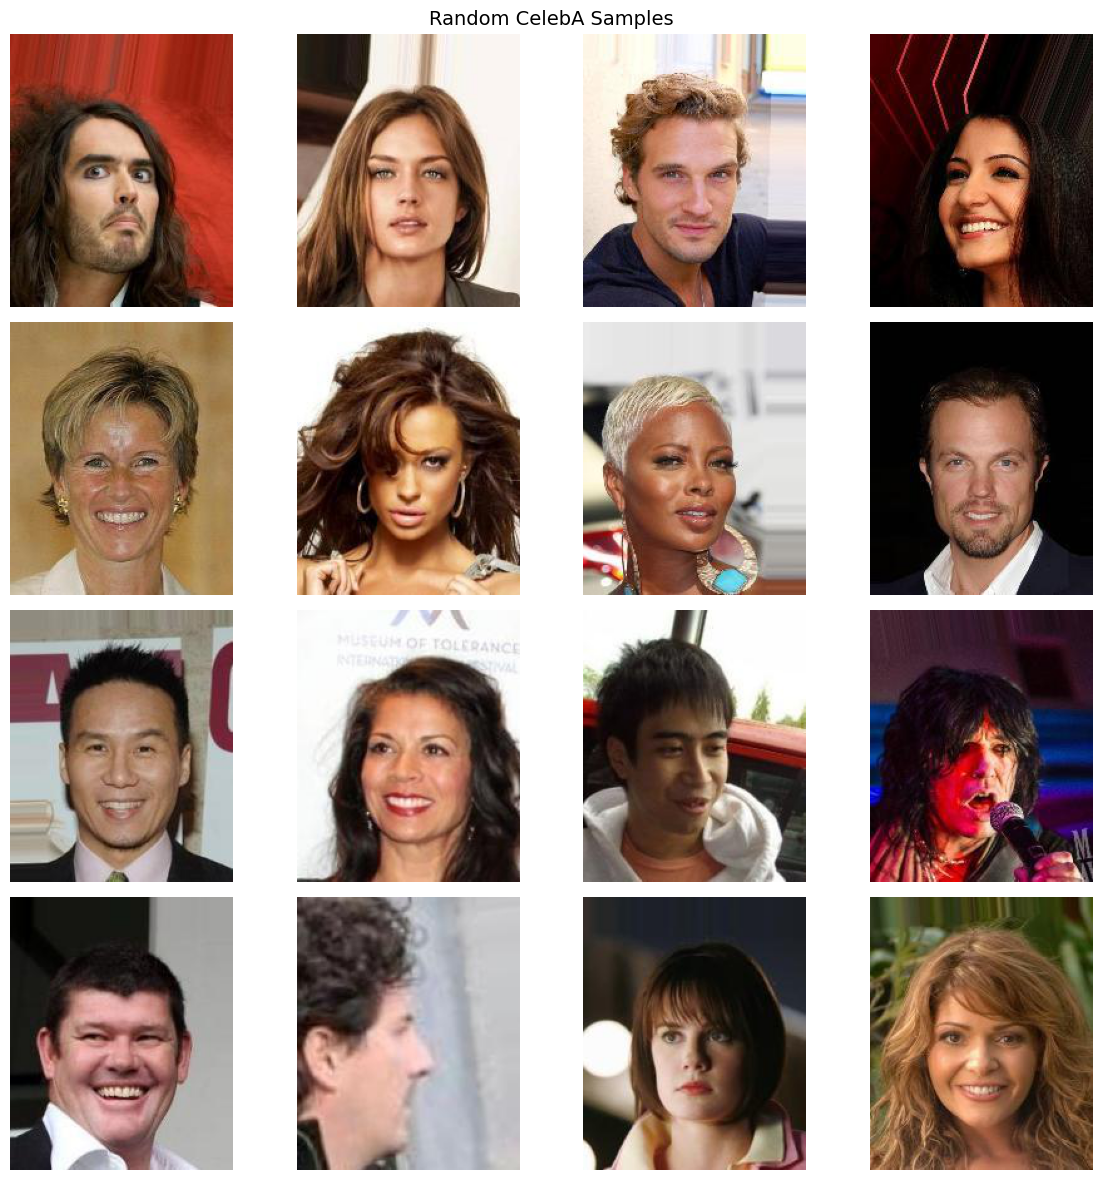

In [19]:
sample = df.sample(16, random_state=42)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img_path = IMG_DIR / row['image_id']
    if img_path.exists():
        ax.imshow(Image.open(img_path))
    ax.axis('off')
plt.suptitle('Random CelebA Samples', fontsize=14)
plt.tight_layout()
plt.show()

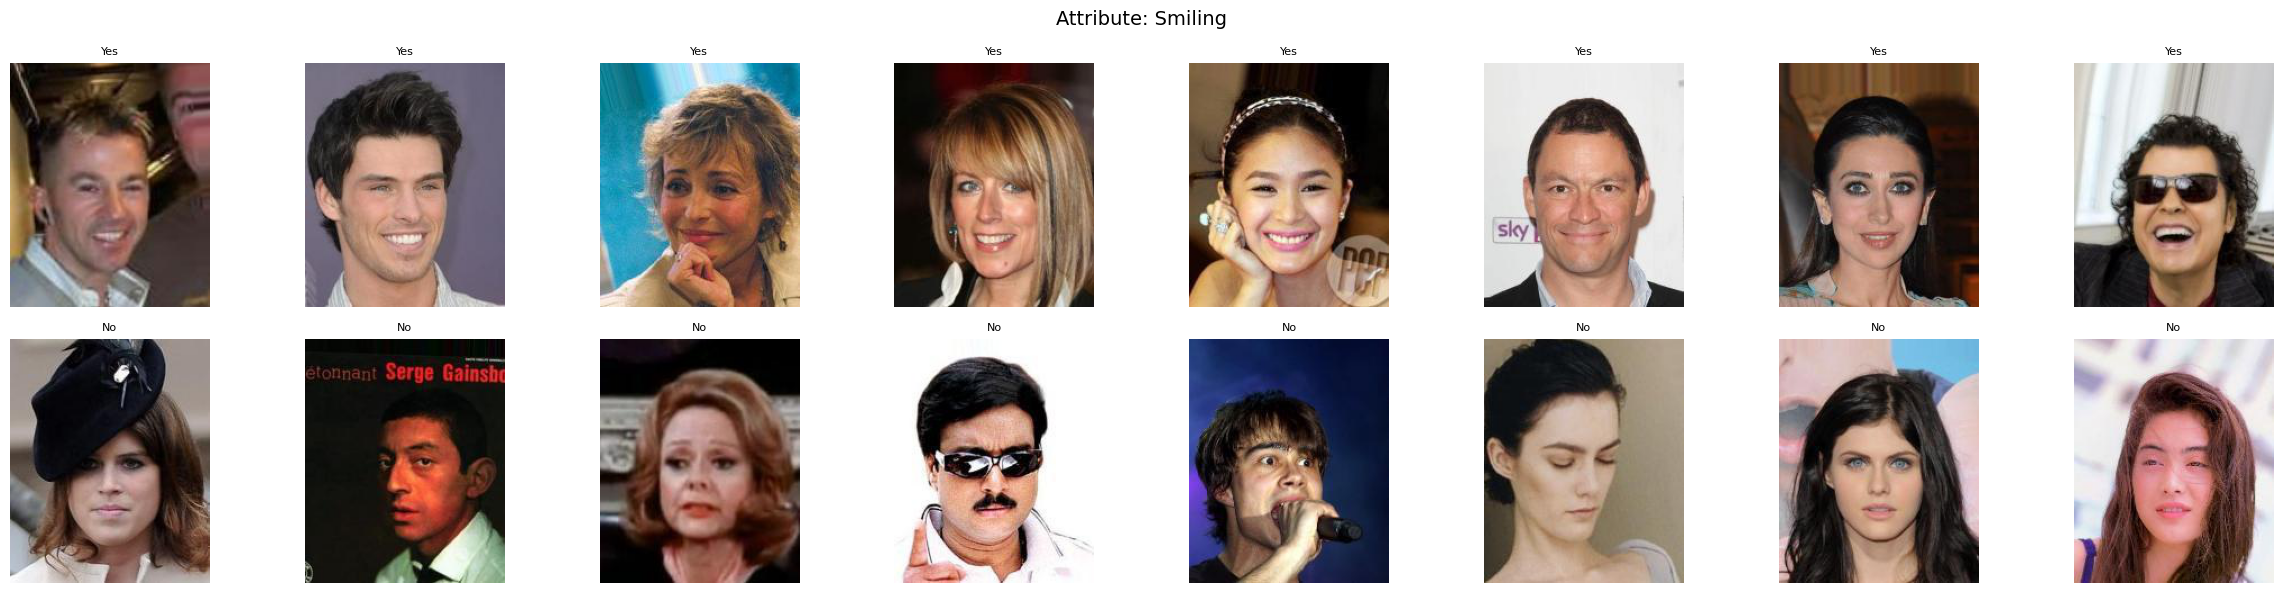

In [20]:
# Positive vs Negative comparison for a specific attribute
INSPECT_ATTR = 'Smiling'
fig, axes = plt.subplots(2, 8, figsize=(24, 6))
for label_val, row_axes in zip([1, 0], axes):
    subset = df[df[INSPECT_ATTR] == label_val].sample(8, random_state=42)
    for ax, (_, row) in zip(row_axes, subset.iterrows()):
        img_path = IMG_DIR / row['image_id']
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        ax.set_title(f"{'Yes' if label_val else 'No'}", fontsize=8)
        ax.axis('off')
plt.suptitle(f'Attribute: {INSPECT_ATTR}', fontsize=14)
plt.tight_layout()
plt.show()

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🧹 Data Cleaning</h3>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>⚙️ Data Preprocessing</h3>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🖼️Image Vectorization / Encoding / Digitization </h3>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🎛️ Model Parameters  </h3>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🤖 Modeling — Multi-Label Classification</h3>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📈 Evaluation & Per-Attribute Metrics</h3>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> 🧪 Testing with New Image  </h3>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📝 Summary</h3>
</div>

<div style="background-color: #f0f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #3498db;">

<h4>🤖 Approach</h4>
<ul>
    <li>Loaded <strong>202,599 face images</strong> with 40 binary attribute labels from CelebA</li>

</ul>

<h4>📊 Key Findings</h4>
<ul>

</ul>

</div>